In [1]:
import numpy as np
from numpy.random import default_rng

from chess import Board
from IPython.display import Image, display

import sys

sys.path.append('../src')

import ctypes.util
print("cairo ->", ctypes.util.find_library("cairo"))

import os
os.environ['DYLD_FALLBACK_LIBRARY_PATH'] = "/opt/homebrew/lib:" + os.environ.get('DYLD_FALLBACK_LIBRARY_PATH','')
import cairosvg  # now it should find libcairo

from games.chess import KRK
from AlphaZero.alpha_zero import GameSearchTree

cairo -> /opt/homebrew/lib/libcairo.dylib


In [2]:
seed = 4
rng = default_rng(seed)

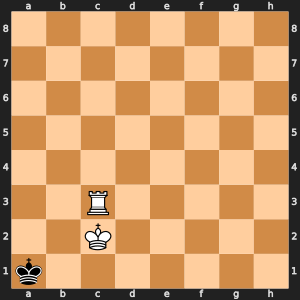

In [3]:
game = KRK()
state = game.initial_state
game.render(state)

In [4]:
from stable_baselines3.a2c import A2C

from agents.utils import ChessEncoder
from agents.random_agent import RandomAgent
from agents.random_policy import GameUniformPolicy
from games.game_utils import GymEnvFromGameAndPlayer2

random_policy = GameUniformPolicy(
    game=game,
    rng=rng,
    encoder=None
)

pl2 = RandomAgent(
    policy=random_policy,
    rng=rng
)
encoder = ChessEncoder()
env = GymEnvFromGameAndPlayer2(
    game=game,
    other_player=pl2,
    encoder=encoder
)

sbl_agent = A2C('MlpPolicy', env, verbose=0)

In [5]:
sbl_agent.policy

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=65, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=65, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=30, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

In [6]:
import torch

# device = 'cuda'
device = 'cpu'

def value_network(state):
    # Convert state to tensor
    tensor = torch.tensor(state, dtype=torch.float32).to(device)
    # Add batch dimension
    tensor = tensor.unsqueeze(dim=0)
    # Get value prediction from the policy
    with torch.no_grad():
        value = sbl_agent.policy.predict_values(tensor)
    return value

def policy_network(state):
    # Convert state to tensor
    tensor = torch.tensor(state, dtype=torch.float32).to(device)
    # Add batch dimension
    tensor = tensor.unsqueeze(dim=0)
    # Get value prediction from the policy
    with torch.no_grad():
        distribution = sbl_agent.policy.get_distribution(tensor)
        probs = distribution.distribution.probs
    return probs


result = env.reset()
state = result[0]

print(f"Value state: {value_network(state)}")
print(f"Policy: {policy_network(state)} (shape: {policy_network(state).shape})")

Value state: tensor([[0.0485]])
Policy: tensor([[0.0333, 0.0333, 0.0332, 0.0333, 0.0334, 0.0335, 0.0335, 0.0333, 0.0336,
         0.0332, 0.0338, 0.0333, 0.0331, 0.0334, 0.0334, 0.0331, 0.0332, 0.0333,
         0.0335, 0.0333, 0.0331, 0.0334, 0.0332, 0.0336, 0.0332, 0.0331, 0.0333,
         0.0332, 0.0332, 0.0337]]) (shape: torch.Size([1, 30]))


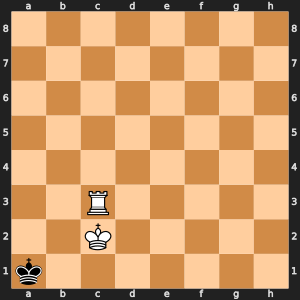

In [7]:
# Initialize game, random policy and MCTS parameters
game = KRK(start_position=1)

params = {
    "puct_constant": 1,
    "value_network": value_network,
    "policy_network": policy_network,
    "encoder": encoder,
    "n_iterations": 10,
    "rng":rng
}

state = game.initial_state

tree = GameSearchTree(
    root=state,
    game=game,
    **params
)

# Show initial state
root = game.initial_state
game.render(state)

In [8]:
# Show best action
best_action = tree.make_decision()
print('Best action:', best_action)

Best action: c3a3


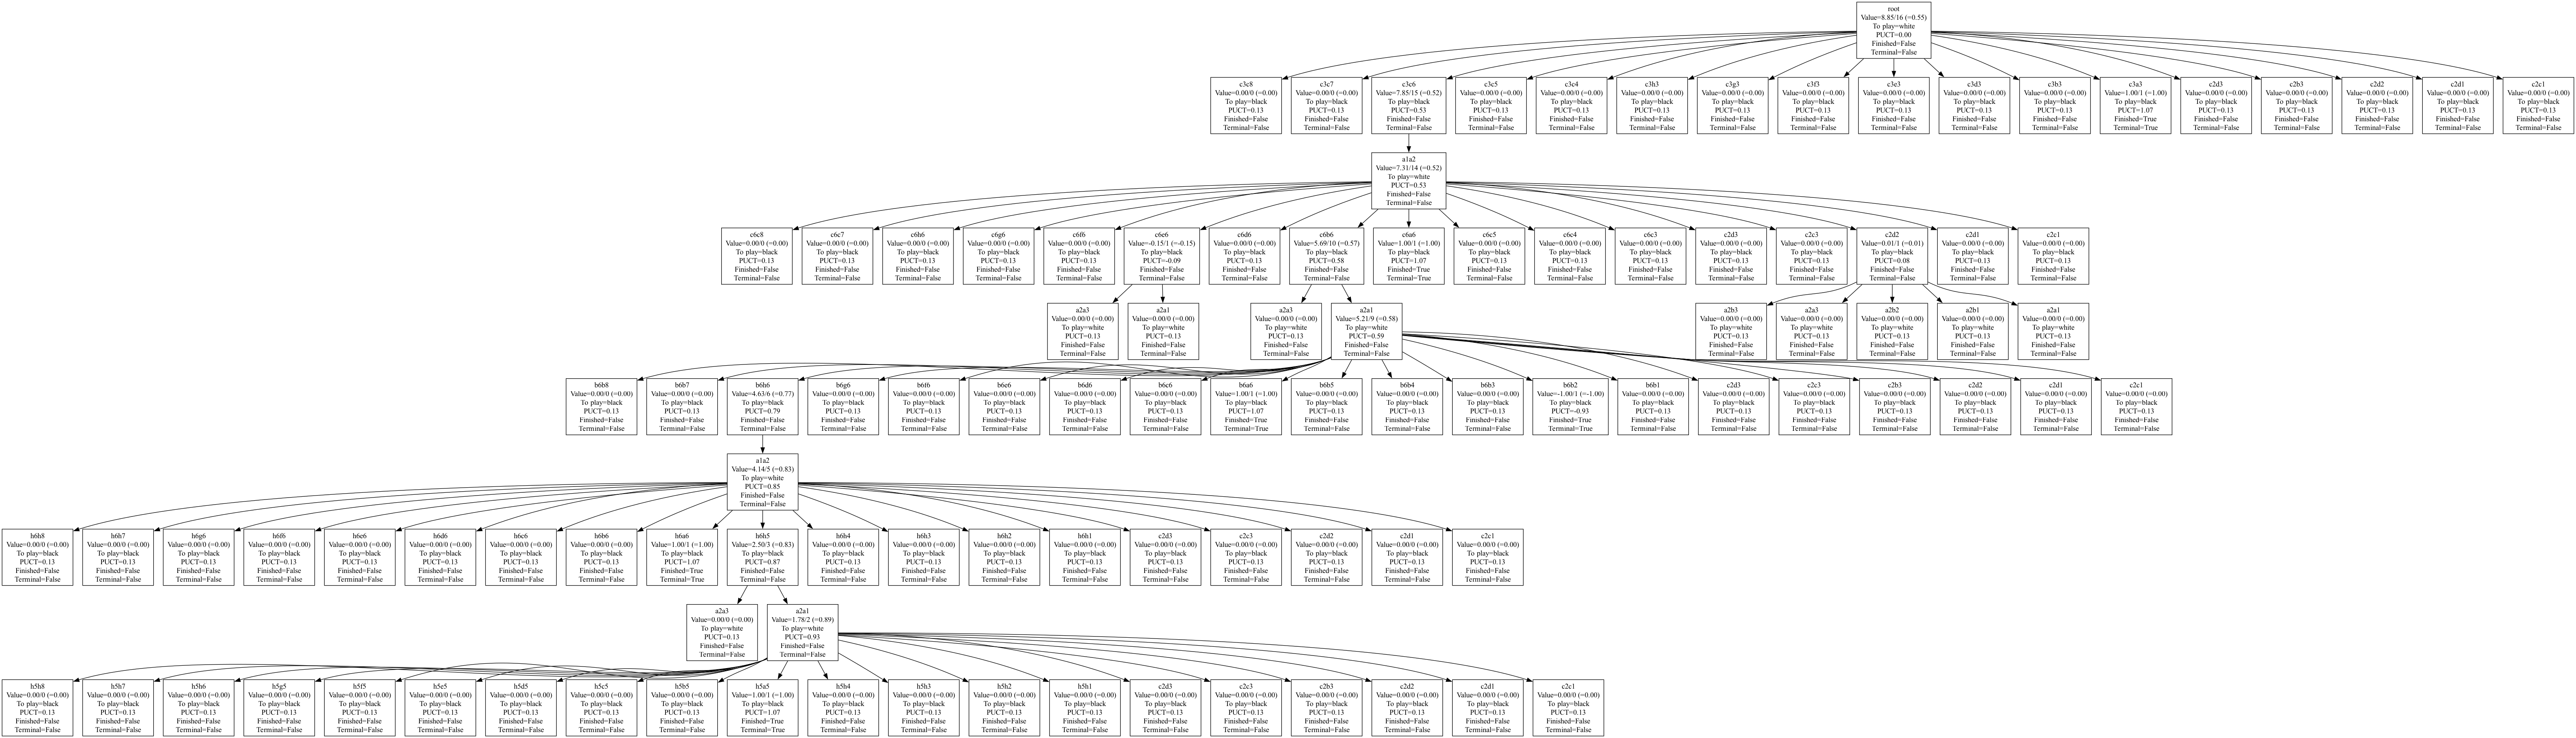

In [9]:
png_data = tree.to_pydot().create_png()
display(Image(png_data))

Best action: c3a3
Game over. White wins!
Board utility: 1


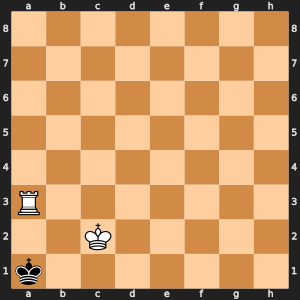

In [10]:
# 

# Show best action
best_action = tree.make_decision()
print('Best action:', best_action)

# Make transition
state = tree.game.result(tree.root.state, best_action)
if tree.game.is_terminal(state):
    game.announce_result(state)
    utility = game.utility(state)
    print('Board utility:', utility)

# Prepare for next iteration
root = tree.get_root_child_from_action(best_action)

# Render
game.render(state)

In [11]:

from AlphaZero.alpha_zero import AlphaZeroDataset

# Example usage
dataset = AlphaZeroDataset(tree)

dataset.add(tree.root)

dataloader = dataset.create_dataloader(batch_size=1)


for states, target_policies, target_values in dataloader:

    print("States:")
    print(states)

    print("\nPolicies:")
    print(target_policies)

    print("\nRoot values:")
    print(target_values)

    print("\n---")

States:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.]])

Policies:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.]])

Root values:
tensor([0.5432])

---


/Users/edgar/Documents/GitHub/ChessFinalistMCTS/notebooks/../src/AlphaZero/alpha_zero.py:648: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(state, dtype=torch.float32).to(self.device),


In [12]:
# =====================================================
# TRAINING LOOP
# =====================================================
policy = sbl_agent.policy
optimizer = sbl_agent.policy.optimizer

for states, target_pi, target_z in dataloader:

    # ---------------------------------
    # Forward pass through shared encoder
    # ---------------------------------

    features = policy.extract_features(states)

    latent_pi, latent_vf = policy.mlp_extractor(features)

    # ---------------------------------
    # POLICY HEAD
    # ---------------------------------

    pred_pi_logits = policy.action_net(latent_pi)
    # print(f"pred_pi_logits: {pred_pi_logits}")

    # ---------------------------------
    # VALUE HEAD
    # ---------------------------------

    pred_v = policy.value_net(latent_vf)

    # ---------------------------------
    # VALUE LOSS
    # ---------------------------------

    value_loss = torch.mean(
        (target_z - pred_v.squeeze()) ** 2
    )

    # ---------------------------------
    # POLICY LOSS
    # ---------------------------------

    log_probs = torch.log_softmax(
        pred_pi_logits,
        dim=1,
    )
    print(f"log_probs: {log_probs.shape}")
    print(f"target_pi: {target_pi.shape}")

    policy_loss = -torch.mean(
        torch.sum(
            target_pi * log_probs,
            dim=1,
        )
    )

    # ---------------------------------
    # L2 REGULARIZATION
    # ---------------------------------

    l2_lambda = 1e-4

    l2_loss = sum(
        p.pow(2).sum()
        for p in policy.parameters()
    )

    # ---------------------------------
    # TOTAL LOSS
    # ---------------------------------

    loss = (
        value_loss
        + policy_loss
        + l2_lambda * l2_loss
    )

    # ---------------------------------
    # OPTIMIZATION STEP
    # ---------------------------------

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(
        f"value_loss={value_loss.item():.4f} | "
        f"policy_loss={policy_loss.item():.4f} | "
        f"total={loss.item():.4f}"
    )

log_probs: torch.Size([1, 30])
target_pi: torch.Size([1, 30])
value_loss=0.2448 | policy_loss=-0.0000 | total=0.2961


In [13]:
from AlphaZero.alpha_zero import SelfPlay

self_play = SelfPlay(
    agent=sbl_agent,
    start_position=2,
    puct_constant=1,
    n_iterations=10,
)

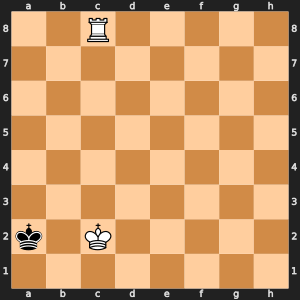

In [14]:
self_play.step()
self_play.game.render(self_play.root.state)

In [15]:
dl = self_play.dataset.create_dataloader(batch_size=1)
len(dl)

1

In [17]:
self_play.train_epoch()